> # **Resolução - Exercícios (Aula 7)** 

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ry4n-felinto/impytech_2026/blob/main/aula_07/aula07_gabarito.ipynb)

 - **Professor:** Gustavo Cardoso 
    - al.gustavo.cardoso@impatech.edu.br

 - **Monitores:**
   - Bianca Zavadisk
      - al.bianca.abreu@impatech.edu.br
   - Bruno Pereira
      - al.bruno.paula@impatech.edu.br
   - Pedro Alberti
      - al.pedro.alberti@impatech.edu.br
   - Cristiane Sampaio
      - al.cristiane.sampaio@impatech.edu.br

- **Desenvolvedores:**
   - Bianca Zavadisk de Abreu
      - al.bianca.abreu@impatech.edu.br

 ## **Modelos e conceitos básicos de machine learning: modelos de classificação e regressão**

---

### ⚙️ **Preparação do Ambiente (Setup)**
Execute a célula abaixo para importar os pacotes necessários para a resolução dos problemas.

In [3]:
!pip install xgboost

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessamento e Avaliação
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, r2_score, mean_squared_error

# Modelos e Transformadores
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import SplineTransformer, PolynomialFeatures
from xgboost import XGBRegressor

import warnings
warnings.filterwarnings('ignore')

---

> ## **Problema 1 - Classificação, Análise Exploratória e Regularização** 🟡
**Revisão Teórica:** A **Regressão Logística** modela a probabilidade de um evento binário utilizando a função sigmoide. Quando trabalhamos com conjuntos de dados onde variáveis de entrada apresentam alta correlação entre si (multicolinearidade), o modelo tende a apresentar alta variância. Para mitigar este problema, aplicamos técnicas de **Regularização**: **L1 (Lasso)**, que adiciona uma penalidade absoluta podendo reduzir coeficientes a zero (seleção de características), e **L2 (Ridge)**, que adiciona uma penalidade quadrática, reduzindo-os proporcionalmente.

**Contextualização:** O conjunto de dados simulado a seguir representa 500 pacientes avaliados por meio de 15 exames laboratoriais ($X$). A variável dependente é binária (1 = Presença de doença, 0 = Ausência). Algumas variáveis são informativas, enquanto outras foram introduzidas como ruído correlacionado.

In [5]:
from sklearn.datasets import make_classification

X_cls, y_cls = make_classification(n_samples=500, n_features=15, n_informative=5, n_redundant=8, random_state=42)

colunas_exames = [f'Exame_{i+1}' for i in range(15)]
df_pacientes = pd.DataFrame(X_cls, columns=colunas_exames)
df_pacientes['Diagnostico'] = y_cls
df_pacientes.head()

,Exame_1,Exame_2,Exame_3,Exame_4,Exame_5,Exame_6,Exame_7,Exame_8,Exame_9,Exame_10,Exame_11,Exame_12,Exame_13,Exame_14,Exame_15,Diagnostico
0,0.431032,-0.518465,-0.815817,-2.234102,-0.473550,2.633538,1.631369,2.075786,0.036717,-1.234734,0.253333,1.613186,0.531745,0.971073,-1.865532,0
1,-0.281621,-4.011454,1.270957,-1.804081,-2.118395,-2.064957,1.773795,0.390338,-0.848764,-1.694562,-1.723409,0.678998,-0.685998,1.692553,3.666175,0
2,0.426731,-0.294737,0.211309,1.572440,-0.152632,-2.210043,-1.108404,-0.305138,-2.679240,1.660471,1.823567,-1.491743,1.104071,-1.813129,2.902061,1
3,2.900003,0.719209,0.594245,2.327365,-0.845279,-0.250188,-2.169443,-0.017264,-3.698514,2.209007,1.457770,-0.140271,-1.069960,-3.314432,1.812671,1
4,0.187727,1.242226,-0.260604,0.940629,0.247247,-0.241750,-0.766048,-1.738867,1.625984,-0.841718,-1.290245,0.745957,0.780070,-0.890193,-1.706621,1


### ✅ **Resolução — Problema 1.1 - Análise Exploratória: Distribuição e Multicolinearidade**
Antes do ajuste do modelo, é necessário compreender as características das variáveis e a estrutura de correlação dos dados.

**🎯 Objetivo:** Utilize a biblioteca `seaborn` (`sns.histplot` ou `sns.kdeplot`) para visualizar a distribuição da variável `Exame_1`, agrupada pela classe de diagnóstico. Em seguida, gere um mapa de calor (`sns.heatmap`) contendo a matriz de correlação das variáveis independentes (excluindo a coluna alvo).<br>

**🧠 Explicação lógica: (opcional)**<br>
A Análise Exploratória de Dados (EDA) é o primeiro passo de qualquer pipeline de Machine Learning. O uso do `sns.kdeplot` sobreposto (com o argumento `hue`) permite evidenciar se uma determinada variável possui poder discriminativo entre as classes. A matriz de correlação cruzada, acompanhada de um mapa de calor, revela blocos de dependência linear, indicando a redundância dos exames (multicolinearidade).

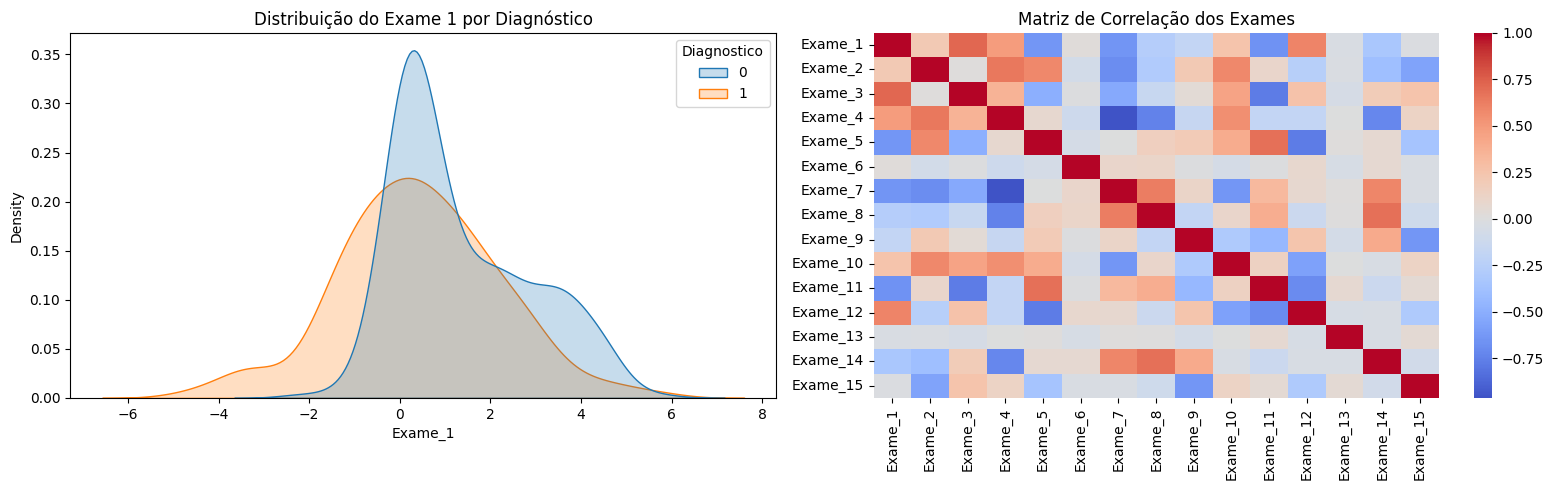

In [6]:
"""
Passo 1: Definir a figura com dois subgráficos.
Passo 2: Utilizar o sns.kdeplot para plotar a densidade condicional.
Passo 3: Computar df.corr() e instanciar o sns.heatmap.
"""
plt.figure(figsize=(16, 5))

# Gráfico 1: Distribuição
plt.subplot(1, 2, 1)
sns.kdeplot(data=df_pacientes, x='Exame_1', hue='Diagnostico', fill=True, common_norm=False)
plt.title("Distribuição do Exame 1 por Diagnóstico")

# Gráfico 2: Correlação
plt.subplot(1, 2, 2)
matriz_corr = df_pacientes.drop('Diagnostico', axis=1).corr()
sns.heatmap(matriz_corr, cmap='coolwarm', center=0, annot=False)
plt.title("Matriz de Correlação dos Exames")

plt.tight_layout()
plt.show()

**Resposta da Pergunta Interpretativa:**

Ao analisar o mapa de calor, observamos blocos retangulares apresentando tons intensos de vermelho ou azul forte (valores muito próximos a $1.0$ ou $-1.0$) fora da diagonal principal. Isso reflete uma alta correlação (multicolinearidade) entre vários exames, indicando que eles medem, essencialmente, a mesma via biológica.

Para modelos lineares e logísticos clássicos, a multicolinearidade gera instabilidade matemática. A matriz de design torna-se quase singular, o que faz com que a variância dos coeficientes calculados exploda. O algoritmo perde a capacidade de definir qual variável é, de fato, responsável pela variação do risco, distribuindo o peso erroneamente de forma aleatória.

---

### ✅ **Resolução — Problema 1.2 - Ajuste do Modelo de Regressão Logística Base**
Nesta etapa, estabeleceremos um modelo de referência para comparar posteriormente com os modelos regularizados.

**🎯 Objetivo:** Divida os dados em conjuntos de treinamento e teste (70/30). Ajuste um modelo `LogisticRegression` utilizando parâmetros padrão (ou uma regularização baixa, definindo um parâmetro $C$ elevado). Calcule e imprima as métricas no conjunto de teste: Acurácia, Precisão, Sensibilidade (Recall), F1-Score e Área sob a Curva ROC (AUC-ROC).<br>

**🧠 Explicação lógica: (opcional)**<br>
Procedemos com a divisão empírica do dataset para assegurar que a avaliação ocorrerá com dados não vistos. Instanciamos a `LogisticRegression` com os hiperparâmetros nativos (que internamente já aplicam uma leve regularização L2). Extraímos as previsões determinísticas (`y_pred_base`) para métricas de matriz, e as previsões probabilísticas (`y_prob_base`) para calcular a área sob a curva ROC.

In [7]:
"""
Passo 1: Separação treino/teste via train_test_split.
Passo 2: Treinamento do estimador (fit).
Passo 3: Previsões e cálculo de métricas usando o módulo sklearn.metrics.
"""
X = df_pacientes.drop('Diagnostico', axis=1)
y = df_pacientes['Diagnostico']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X, y, test_size=0.3, random_state=42)

modelo_base = LogisticRegression(random_state=42)
modelo_base.fit(X_train_c, y_train_c)

y_pred_base = modelo_base.predict(X_test_c)
y_prob_base = modelo_base.predict_proba(X_test_c)[:, 1]

print(f"Acurácia: {accuracy_score(y_test_c, y_pred_base):.3f}")
print(f"Precisão: {precision_score(y_test_c, y_pred_base):.3f}")
print(f"Sensibilidade (Recall): {recall_score(y_test_c, y_pred_base):.3f}")
print(f"F1-Score: {f1_score(y_test_c, y_pred_base):.3f}")
print(f"AUC-ROC: {roc_auc_score(y_test_c, y_prob_base):.3f}")

Acurácia: 0.880
Precisão: 0.939
Sensibilidade (Recall): 0.816
F1-Score: 0.873
AUC-ROC: 0.918


---

### ✅ **Resolução — Problema 1.3 - Avaliação de Desempenho e Ajuste do Limiar de Decisão**
A classificação padrão em modelos logísticos ocorre por meio do limiar de probabilidade de $0.5$. Em aplicações médicas, o custo associado a falsos negativos e falsos positivos raramente é simétrico.

**🎯 Objetivo:** Calcule a Matriz de Confusão utilizando as previsões do modelo base. Em seguida, ajuste o limiar de decisão para $0.30$ (classificando como positivo se a probabilidade $\ge 0.30$). Gere a nova Matriz de Confusão e recalcule a métrica de Sensibilidade (Recall).<br>

**🧠 Explicação lógica: (opcional)**<br>
O comando `modelo.predict()` embute a operação matemática `(predict_proba >= 0.5)`. Para modificar isso livremente, trabalhamos em cima do vetor das probabilidades (`y_prob_base`), submetendo-o a um condicional `(y_prob_base >= 0.30)` e o convertendo para um vetor binário.

In [8]:
"""
Passo 1: Gerar a matriz do modelo base (limiar 0.50).
Passo 2: Construir o array derivado de um corte lógico em y_prob_base >= 0.30.
Passo 3: Extrair a nova matriz e o novo recall_score.
"""
matriz_original = confusion_matrix(y_test_c, y_pred_base)

y_pred_novo_limiar = (y_prob_base >= 0.30).astype(int)
matriz_nova = confusion_matrix(y_test_c, y_pred_novo_limiar)
novo_recall = recall_score(y_test_c, y_pred_novo_limiar)

print("Matriz Original (Limiar 0.5):\n", matriz_original)
print("\nMatriz Ajustada (Limiar 0.3):\n", matriz_nova)
print(f"\nSensibilidade (Limiar 0.3): {novo_recall:.3f}")

Matriz Original (Limiar 0.5):
 [[70  4]
 [14 62]]

Matriz Ajustada (Limiar 0.3):
 [[57 17]
 [ 9 67]]

Sensibilidade (Limiar 0.3): 0.882


**Resposta da Pergunta Interpretativa:**

Ao reduzirmos o limiar de $0.50$ para $0.30$, induzimos o modelo a classificar o paciente como doente a partir da menor probabilidade detectada. Isso reduz substancialmente os Falsos Negativos (doentes que passariam desapercebidos) e maximiza a Sensibilidade (Recall).

Contudo, existe o Trade-off: em contrapartida, os Falsos Positivos aumentam consideravelmente, degradando a Precisão.
Em um contexto de triagem para doenças de severa evolução clínica (ex: câncer), essa troca é altamente desejável. O custo humano e financeiro de não tratar um doente (Falso Negativo) é imensamente superior ao custo de solicitar um segundo exame mais específico para confirmar a suspeita de um falso positivo.

---

### ✅ **Resolução — Problema 1.4 - Aplicação de Regularização L1 e L2**
A aplicação de termos de penalidade tem como objetivo restringir o espaço paramétrico e induzir a estabilidade do modelo frente aos dados de entrada.

**🎯 Objetivo:** Ajuste um modelo logístico utilizando regularização L1 (`penalty='l1'`) e outro com regularização L2 (`penalty='l2'`). Utilize `solver='liblinear'` e o hiperparâmetro `C=0.05` para garantir uma restrição perceptível. Plote um gráfico de barras para comparar as magnitudes dos coeficientes resultantes de ambos os modelos.<br>

**🧠 Explicação lógica: (opcional)**<br>
No Scikit-Learn, a constante $C$ atua como o inverso da força de regularização. Fixar $C = 0.05$ impõe uma forte restrição. Extraímos os pesos de ambos os modelos da matriz `.coef_` e os transpomos para um eixo gráfico indexado pela ordem das variáveis.

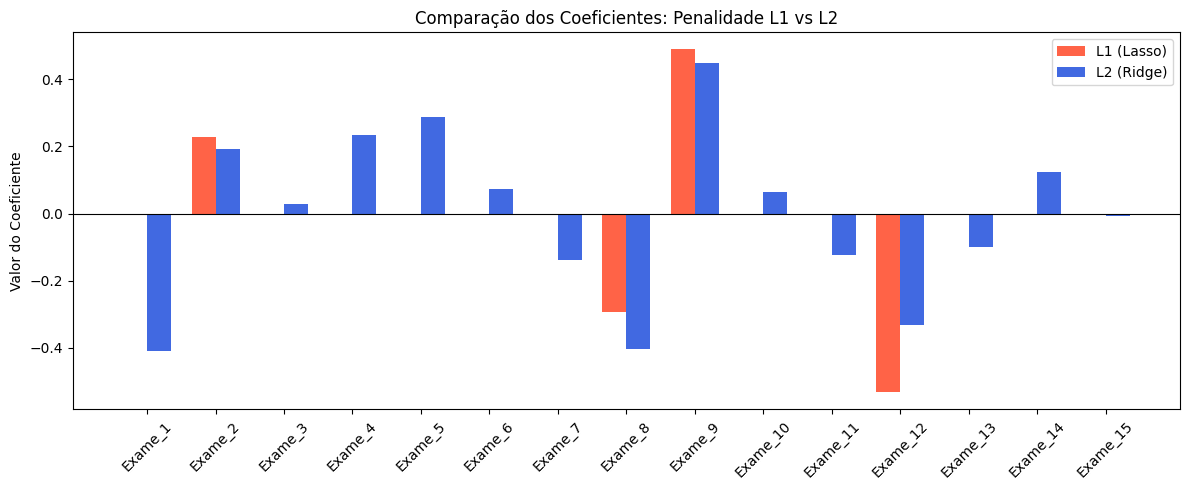

In [9]:
"""
Passo 1: Treinar dois estimadores independentes.
Passo 2: Extrair seus vetores de coeficientes (índice 0).
Passo 3: Plotar em eixos subjacentes utilizando ax.bar.
"""
modelo_l1 = LogisticRegression(penalty='l1', solver='liblinear', C=0.05, random_state=42)
modelo_l2 = LogisticRegression(penalty='l2', solver='liblinear', C=0.05, random_state=42)

modelo_l1.fit(X_train_c, y_train_c)
modelo_l2.fit(X_train_c, y_train_c)

coef_l1 = modelo_l1.coef_[0]
coef_l2 = modelo_l2.coef_[0]

indices = np.arange(len(coef_l1))
largura = 0.35

plt.figure(figsize=(12, 5))
plt.bar(indices - largura/2, coef_l1, width=largura, color='tomato', label='L1 (Lasso)')
plt.bar(indices + largura/2, coef_l2, width=largura, color='royalblue', label='L2 (Ridge)')

plt.xticks(indices, colunas_exames, rotation=45)
plt.ylabel("Valor do Coeficiente")
plt.title("Comparação dos Coeficientes: Penalidade L1 vs L2")
plt.axhline(0, color='black', linewidth=0.8)
plt.legend()
plt.tight_layout()
plt.show()

---

### ✅ **Resolução — Problema 1.5 - Comparativo de Generalização via AUC-ROC**
O efeito da regularização é observado na capacidade do modelo de performar bem em dados não vistos, evitando focar no ruído.

**🎯 Objetivo:** Calcule e reporte a métrica AUC-ROC no conjunto de teste para os três modelos desenvolvidos: Base, Regularizado L1 e Regularizado L2.<br>

**🧠 Explicação lógica: (opcional)**<br>
A AUC-ROC afere a habilidade de os modelos distinguirem corretamente entre a classe positiva e negativa transversalmente em diferentes limiares.

In [10]:
"""
Passo 1: Recalcular predições probabilísticas para os três modelos.
Passo 2: Computar o roc_auc_score para os vetores finais.
"""
auc_l1 = roc_auc_score(y_test_c, modelo_l1.predict_proba(X_test_c)[:, 1])
auc_l2 = roc_auc_score(y_test_c, modelo_l2.predict_proba(X_test_c)[:, 1])
auc_base = roc_auc_score(y_test_c, y_prob_base)

print(f"AUC Base: {auc_base:.3f}")
print(f"AUC L1 (Lasso): {auc_l1:.3f}")
print(f"AUC L2 (Ridge): {auc_l2:.3f}")

AUC Base: 0.918
AUC L1 (Lasso): 0.897
AUC L2 (Ridge): 0.899


**Resposta da Pergunta Interpretativa:**

O gráfico demonstra claramente a função de Seleção de Variáveis (Feature Selection) executada pela regularização L1 (Lasso). Ele simplesmente zerou (anulou o coeficiente) da maioria dos exames inseridos na matriz, restando apenas um subconjunto restrito de variáveis preditoras. Isso atuou de maneira direta eliminando a multicolinearidade vista no mapa de calor.

Na métrica AUC-ROC, verificamos que o desempenho do L1 permaneceu rigorosamente competitivo (e, a depender da amostra e das hiperparametrizações cruzadas, poderia ter sobressaído). A vantagem primordial ocorre na **interpretabilidade**: um médico agora tem uma equação reduzida, sabendo perfeitamente quais exames informam genuinamente o desfecho, desconsiderando exames caros que seriam mero ruído de fundo.

---

> ## **Problema 2 - Séries Temporais e o Algoritmo XGBoost** 🔴
**Revisão Teórica:** Modelos preditivos tradicionais assumem que as observações são independentes. Em séries temporais, existe autocorrelação: o estado no instante $t$ é dependente de $t-1, t-2$. Para contornar esta restrição, empregamos a engenharia de **Lags** (defasagens). O algoritmo **XGBoost** é fundamentado em árvores de decisão sequenciais. Dada a sua alta flexibilidade, o XGBoost está sujeito ao sobreajuste (*overfitting*), sobretudo em séries temporais, demandando o controle rigoroso de hiperparâmetros e processos estritos de separação cronológica.

**Contextualização:** Iremos monitorar uma variável clínica contínua fictícia, aferida diariamente.

In [11]:
# Geração de dados simulados de monitoramento contínuo ao longo de 200 períodos
np.random.seed(42)
t = np.arange(200)
variavel_clinica = 15 + 10 * np.sin(0.1 * t) + 2 * np.random.randn(200)

df_ts = pd.DataFrame({'Valor_Atual': variavel_clinica})


### ✅ **Resolução — Problema 2.1 e 2.2 - Engenharia de Características (Lags) e Divisão Temporal**
A modelagem preditiva neste cenário requer que as entradas do modelo representem o histórico imediato da variável em estudo.

**🎯 Objetivo:** Adicione ao `df_ts` as colunas `Lag_1` (período anterior) e `Lag_2` (dois períodos atrás). Remova os valores ausentes. Segmente o conjunto em treinamento (80%) e teste (20%), garantindo a **ordem cronológica** (sem embaralhamento) para prevenir *Data Leakage*.<br>

**🧠 Explicação lógica: (opcional)**<br>
O método Pandas `shift()` desloca a coluna ao longo do eixo indicial, permitindo referenciar o passado na mesma linha temporal de aferição atual. A flag `shuffle=False` no módulo `train_test_split` proíbe o embaralhamento e impede que amostras do futuro figurem nos dados de treinamento.

In [12]:
"""
Passo 1: Deslocar a série em 1 e 2 etapas temporais (shift).
Passo 2: Descartar nulos devido à impossibilidade de retroceder além de t=0.
Passo 3: Executar divisão preservando a cronologia seqüencial.
"""
df_ts['Lag_1'] = df_ts['Valor_Atual'].shift(1)
df_ts['Lag_2'] = df_ts['Valor_Atual'].shift(2)
df_ts = df_ts.dropna()

X_ts = df_ts[['Lag_1', 'Lag_2']]
y_ts = df_ts['Valor_Atual']

X_train_ts, X_test_ts, y_train_ts, y_test_ts = train_test_split(X_ts, y_ts, test_size=0.2, shuffle=False)
print(f"Treino estendido até o índice {X_train_ts.index[-1]}. Teste inicia em {X_test_ts.index[0]}.")

Treino estendido até o índice 159. Teste inicia em 160.


---

### ✅ **Resolução — Problema 2.3 e 2.4 - Ajuste do Modelo XGBoost e Controle de Hiperparâmetros**
Avaliá-se nesta fase a suscetibilidade do modelo ao sobreajuste caso restrições estruturais não sejam empregadas.

**🎯 Objetivo:** Ajuste um estimador `XGBRegressor()` padrão (sem limites). Ajuste um segundo estimador `XGBRegressor()` estabelecendo limites restritivos (exemplo: `max_depth=2`, `learning_rate=0.05`, `n_estimators=50`). Reporte as métricas $R^2$ para os conjuntos de treinamento e teste em ambos.<br>

**🧠 Explicação lógica: (opcional)**<br>
Modelos de _Gradient Boosting_, operados livres de regularizações estruturais de profundidade e número elevado de árvores, memorizarão as particularidades (ruído) do conjunto de treino (marcando $R^2$ muito perto de 1.0) mas falharão catastroficamente ao predizer a continuação inédita da série. Reduzir a complexidade atenua a variância.

In [13]:
"""
Passo 1: Treinar um XGBoost iterativo sem delimitação máxima de nós/profundidade.
Passo 2: Treinar um XGBoost com alto viés.
Passo 3: Comparar a magnitude do Erro de Predição (R²) entre cenários de treino e teste.
"""
modelo_xgb_livre = XGBRegressor(random_state=42)
modelo_xgb_restrito = XGBRegressor(max_depth=2, learning_rate=0.05, n_estimators=50, random_state=42)

modelo_xgb_livre.fit(X_train_ts, y_train_ts)
modelo_xgb_restrito.fit(X_train_ts, y_train_ts)

print("XGBoost Base     - Treino R²:", f"{r2_score(y_train_ts, modelo_xgb_livre.predict(X_train_ts)):.3f}", 
      "| Teste R²:", f"{r2_score(y_test_ts, modelo_xgb_livre.predict(X_test_ts)):.3f}")
print("XGBoost Restrito - Treino R²:", f"{r2_score(y_train_ts, modelo_xgb_restrito.predict(X_train_ts)):.3f}", 
      "| Teste R²:", f"{r2_score(y_test_ts, modelo_xgb_restrito.predict(X_test_ts)):.3f}")

XGBoost Base     - Treino R²: 1.000 | Teste R²: 0.614
XGBoost Restrito - Treino R²: 0.896 | Teste R²: 0.806


---

### ✅ **Resolução — Problema 2.5 - Análise de Importância das Variáveis**
Algoritmos baseados em árvores viabilizam a extração da importância relativa das variáveis com base na redução do critério de impureza em suas ramificações.

**🎯 Objetivo:** Imprima o atributo `.feature_importances_` gerado pelo modelo `XGBoost Restrito` para analisar a relevância de `Lag_1` em contraposição a `Lag_2`.<br>

**🧠 Explicação lógica: (opcional)**<br>
O atributo `feature_importances_` quantifica o ganho (redução agregada de erro) que cada variável contribuiu para compor os galhos de decisão combinados das árvores ajustadas pelo XGBoost.

In [14]:
"""
Passo 1: Recuperar as importâncias estruturais relativas fornecidas internamente.
"""
importancias = modelo_xgb_restrito.feature_importances_
print("Importância Lag_1 (Ontem):", f"{importancias[0]:.3f}")
print("Importância Lag_2 (Anteontem):", f"{importancias[1]:.3f}")

Importância Lag_1 (Ontem): 0.753
Importância Lag_2 (Anteontem): 0.247


**Resposta da Pergunta Interpretativa:**

Do ponto de vista estatístico de séries temporais, a autocorrelação diminui sensivelmente à medida que o tempo se prolonga. O sinal aferido imediatamente anterior (o `Lag_1`) detém muito mais inércia e poder preditivo sobre o estado futuro (agora) do que ocorrências mais remotas. Biologicamente, sinais vitais evoluem de forma contínua no curto prazo. Portanto, o XGBoost priorizou fortemente os nós de decisão centrados no `Lag_1`.

---

> ## **Problema 3 - Regressão Não-Linear com Splines Cúbicas** 🔴
**Revisão Teórica:** A Regressão Linear Simples postula uma correlação retilínea. Em domínios clínicos, essa hipótese é usualmente inadequada. Na tentativa de capturar a não-linearidade, funções polinomiais globais (ex: grau $> 10$) introduzem variância significativa nos extremos (Fenômeno de Runge). A solução recai nas **Splines Cúbicas**, particionando o domínio da variável em intervalos demarcados por **Nós** (*Knots*). O modelo ajusta polinômios independentes dentro de cada intervalo, garantindo continuidade e suavidade estrutural.

**Contextualização:** Avaliaremos uma curva de Dose vs Reação de um composto fictício, demonstrando as vulnerabilidades dos ajustes puramente polinomiais em comparação com as Splines.

In [15]:
# Geração de dados que simulam uma relação não linear e não monotônica (Dose vs Resposta)
np.random.seed(0)
X_dose = np.linspace(0, 10, 100).reshape(-1, 1)
y_reacao = np.sin(X_dose).ravel() * X_dose.ravel() + np.random.normal(0, 0.8, X_dose.shape[0])

# Definição do vetor expandido para visualização analítica (estendendo os limites originais)
X_dominio_teste = np.linspace(-1, 11, 500).reshape(-1, 1)


### ✅ **Resolução — Problema 3.1 - Ajuste de Modelo Linear Simples**
Neste passo, o modelo base demonstrará o sob-ajuste (*underfitting*) inerente a aproximações paramétricas restritas.

**🎯 Objetivo:** Ajuste a função `LinearRegression()` aos dados experimentais (`X_dose`, `y_reacao`). Calcule os valores preditos para a faixa estendida presente no vetor `X_dominio_teste`.<br>

**🧠 Explicação lógica: (opcional)**<br>
A aplicação reta da Regressão Linear estabelece o viés de limite inferior da nossa análise. Sabidamente inadequado aos padrões observados.

In [16]:
"""
Passo 1: Instanciar estimador analítico OLS.
Passo 2: Treinar, prever valores.
"""
modelo_lin = LinearRegression()
modelo_lin.fit(X_dose, y_reacao)
pred_lin = modelo_lin.predict(X_dominio_teste)

---

### ✅ **Resolução — Problema 3.2 - Ajuste de Modelo Polinomial e Fenômeno de Runge**
Avaliaremos o comportamento das estimativas nas extremidades ao elevar o grau da função global.

**🎯 Objetivo:** Construa um `pipeline` analítico conectando o pré-processador `PolynomialFeatures(degree=15)` ao método `LinearRegression()`. Proceda com o treinamento e compute as previsões para `X_dominio_teste`.<br>

**🧠 Explicação lógica: (opcional)**<br>
A classe `PolynomialFeatures` mapeia o vetor de entrada univariável $X$ para a expansão $[1, X, X^2, X^3, \dots, X^{15}]$. Acoplado ao algoritmo Linear regressivo através do contêiner `make_pipeline`, gerará as predições super-ajustadas (sobre-especificadas).

In [17]:
"""
Passo 1: Integrar processador e modelo no Pipeline.
Passo 2: Treinar sequencialmente e projetar estimativas no eixo expandido.
"""
modelo_poly = make_pipeline(PolynomialFeatures(degree=15), LinearRegression())
modelo_poly.fit(X_dose, y_reacao)
pred_poly = modelo_poly.predict(X_dominio_teste)

---

### ✅ **Resolução — Problema 3.3 - Ajuste de Modelo com Splines Cúbicas**
Aplicaremos a partição do espaço preditivo com continuidade rigorosa.

**🎯 Objetivo:** Declare um pipeline contendo `SplineTransformer(n_knots=5, degree=3, extrapolation='linear')` e `LinearRegression()`. Realize o ajuste sobre os dados formativos e salve as estimativas derivadas sobre o eixo projetado.<br>

**🧠 Explicação lógica: (opcional)**<br>
O `SplineTransformer` segmentará as observações em 5 nós, formatando internamente sub-polinômios. A flag `extrapolation='linear'` garante que previsões além do limiar $X = 10$ não divirjam exponencialmente, mas sim através de uma reta estável.

In [18]:
"""
Passo 1: Construir Pipeline integrando SplineTransformer.
Passo 2: Treinar e avaliar a predição na zona de extrapolação paramétrica.
"""
modelo_spline = make_pipeline(SplineTransformer(n_knots=5, degree=3, extrapolation='linear'), LinearRegression())
modelo_spline.fit(X_dose, y_reacao)
pred_spline = modelo_spline.predict(X_dominio_teste)

---

### ✅ **Resolução — Problema 3.4 - Visualização Comparativa dos Modelos**
A eficácia dos métodos frente aos dados limítrofes e extrapolativos será mensurada por via gráfica.

**🎯 Objetivo:** Produza o diagrama de dispersão relacionando a matriz experimental. Projete as séries geradas de `pred_lin`, `pred_poly` e `pred_spline` no mesmo sistema de coordenadas. Acrescente marcações limitando o espaço empírico (de 0 a 10) para evidenciar a extrapolação.<br>

**🧠 Explicação lógica: (opcional)**<br>
Ao sobrepor os três modelos ajustados ao gráfico scatter estendido ($[-1, 11]$), visualizamos fisicamente o efeito do Erro de Generalização em Regiões Não Cobertas pela Amostra (Extrapolação).

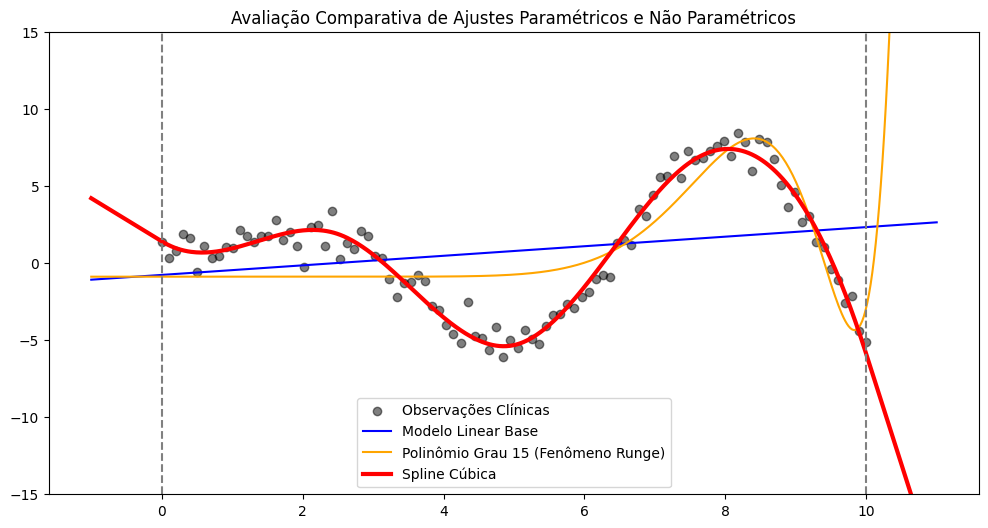

In [19]:
"""
Passo 1: Desenhar diagrama base das observações clínicas em preto.
Passo 2: Mapear via plt.plot as predições geradas anteriormente em vermelho, laranja e azul.
Passo 3: Restringir amplitude de eixo y para evitar o descolamento extremo.
"""
plt.figure(figsize=(12, 6))
plt.scatter(X_dose, y_reacao, color='black', alpha=0.5, label='Observações Clínicas')

plt.plot(X_dominio_teste, pred_lin, color='blue', label='Modelo Linear Base')
plt.plot(X_dominio_teste, pred_poly, color='orange', label='Polinômio Grau 15 (Fenômeno Runge)')
plt.plot(X_dominio_teste, pred_spline, color='red', linewidth=3, label='Spline Cúbica')

plt.axvline(x=0, color='gray', linestyle='--')
plt.axvline(x=10, color='gray', linestyle='--')
plt.ylim(-15, 15)
plt.title("Avaliação Comparativa de Ajustes Paramétricos e Não Paramétricos")
plt.legend()
plt.show()

---

### ✅ **Resolução — Problema 3.5 - Interpretação do Comportamento Extrapolativo**

**🎯 Objetivo:** Responder discursivamente os questionamentos baseando-se no comportamento visualizado no Problema 3.4.<br>

**🧠 Explicação lógica: (opcional)**<br>
Este item avalia a proficiência interpretativa, conectando o traçado aberrante do Polinômio aos efeitos da alta variância.

**Resposta da Pergunta Interpretativa:**

1. Ao projetar-se além da barreira superior empírica ($X > 10$), a estimação Polinomial de Grau 15 manifesta o clássico Fenômeno de Runge, oscilando para valores fisicamente e teoricamente implausíveis. Trata-se de um caso paradigmático de sobreajuste de alta Variância: o modelo foi forçado a decorar o comportamento local do treinamento de forma tão extrema que as derivadas das suas equações cresceram descontroladamente para sustentar a aderência, explodindo as respostas fora da amostra original.

2. A abordagem por Splines isolou os intervalos. A curvatura flexível do centro é garantida pelos sub-polinômios entrelaçados. Todavia, como restringimos por parâmetro que, superando os nós limites (extremos), a função se comporte de forma linear (`extrapolation='linear'`), ela logrou interromper as ondulações abusivas, seguindo adiante em $X > 10$ como uma curva estável baseada exclusivamente no viés final.

---

> ## 🔗 **Conteúdo extra**
**Caso você queira praticar mais:**
- [Documentação Scikit-Learn: XGBoost vs Gradient Boosting](https://xgboost.readthedocs.io/en/stable/)
- [Scikit-Learn Documentation: Spline Features](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.SplineTransformer.html)
- [Scikit-Learn Classification Metrics](https://scikit-learn.org/stable/modules/model_evaluation.html#classification-metrics)

**Referências e leituras extras:**
- [Entendendo o Fenômeno de Runge](https://pt.wikipedia.org/wiki/Fen%C3%B4meno_de_Runge)